In [ ]:
import uproot

In [ ]:
def inspect_jewel_file(file_path):
    with uproot.open(file_path) as file:
        print("Keys in the file:", file.keys())
        # You can also inspect specific keys if needed
        # For example, if you want to see the contents of a specific key:
        # print("Contents of a specific key:", file["key_name"].arrays())
        for k in file.keys():
            try:
                print(f"Contents of key '{k}':", file[k].arrays())
            except Exception as e:
                print(f"Could not read key '{k}': {e}")

In [ ]:
pp_100_GeV_file_path = "/Users/ploskon/data/jewel/fromLuisa/pp_100GeV.root"
inspect_jewel_file(pp_100_GeV_file_path)

In [ ]:
# efficient reading of file contents with uproot to pandas DataFrame
# we want to read trees tracks and event_info
# tracks contains the following branches: eventID, label, px, py, pz, energy -- where label is the particle ID
# event_info contains the following branches: eventID, weight, xsec
# the reader class builds events containing tracks and event info the matching is done by eventID

import pandas as pd
class JewelReader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.tracks_df = None
        self.event_info_df = None

    def read_file(self):
        with uproot.open(self.file_path) as file:
            # Read tracks tree into a DataFrame
            self.tracks_df = file["tracks"].arrays(library="pd")
            # Read event_info tree into a DataFrame
            self.event_info_df = file["event_info"].arrays(library="pd")

    def build_events(self):
        if self.tracks_df is None or self.event_info_df is None:
            raise ValueError("DataFrames are not loaded. Call read_file() first.")
        
        # Merge tracks and event_info on eventID
        events_df = pd.merge(self.tracks_df, self.event_info_df, on="eventID", how="inner")
        return events_df

In [ ]:
# here we demonstrate the usage of the JewelReader class
jewel_reader = JewelReader(pp_100_GeV_file_path)
jewel_reader.read_file()
events_df = jewel_reader.build_events()

# now iterate over the events and print some information about them
for event_id, event in events_df.groupby("eventID"):
    print(f"Event ID: {event_id}")
    print(f"Number of tracks: {len(event)}")
    print(f"Event weight: {event['weight'].iloc[0]}")
    print(f"Event cross-section: {event['xsec'].iloc[0]}")
    print("First 5 tracks:")
    print(event[["label", "px", "py", "pz", "energy"]].head())
    print("\n")

In [ ]:
from yasp import GenericObject
import heppyy.util.fastjet_cppyy
import heppyy.util.heppyy_cppyy

from cppyy.gbl import fastjet as fj
from cppyy.gbl.std import vector

from heppyy.util.mputils import logbins


In [ ]:
# now we want to use the reader class but we want to use the function apply to build events on the fly without loading the entire file into memory
class JewelReader:
    def __init__(self, file_path):
        self.file_path = file_path

    def read_file(self):
        with uproot.open(self.file_path) as file:
            # Read tracks tree into a DataFrame
            tracks_df = file["tracks"].arrays(library="pd")
            # Read event_info tree into a DataFrame
            event_info_df = file["event_info"].arrays(library="pd")
        
        # Merge tracks and event_info on eventID
        events_df = pd.merge(tracks_df, event_info_df, on="eventID", how="inner")
        return events_df
      
    def build_events(self):
        events_df = self.read_file()
        for n, (event_id, event) in enumerate(events_df.groupby("eventID")):
            yield {
                "event_id": event_id,
                "num_tracks": len(event),
                "weight": event["weight"].iloc[0],
                "xsec": event["xsec"].iloc[0],
                "tracks": event[["label", "px", "py", "pz", "energy"]],
                # vector of pseudo-jets for fastjet
                "pseudo_jets": [fj.PseudoJet(px, py, pz, energy) for px, py, pz, energy in zip(event["px"], event["py"], event["pz"], event["energy"])],
                "vector_pseudo_jets": vector[fj.PseudoJet]([fj.PseudoJet(px, py, pz, energy) for px, py, pz, energy in zip(event["px"], event["py"], event["pz"], event["energy"])])
            }
        
      

In [ ]:
# now demonstrate the usage of the JewelReader class with the generator and run a jet clustering algorithm on the pseudojets

from lund_jet import LundJet

lund_jets = []

jewel_reader = JewelReader(pp_100_GeV_file_path)
for event in jewel_reader.build_events():
    print(f"Event ID: {event['event_id']}")
    print(f"Number of tracks: {event['num_tracks']}")
    print(f"Event weight: {event['weight']}")
    print(f"Event cross-section: {event['xsec']}")
    # print("First 5 tracks:")
    # print(event["tracks"].head())
    
    # now run the jet clustering algorithm on the pseudojets
    jet_def = fj.JetDefinition(fj.antikt_algorithm, 0.4)
    cluster_sequence = fj.ClusterSequence(event['vector_pseudo_jets'], jet_def)
    jets = fj.sorted_by_pt(cluster_sequence.inclusive_jets())
    
    print(f"Number of jets found: {len(jets)}")
    print("First 5 jets:")
    for i, jet in enumerate(jets[:5]):
        print(f"Jet {i}: pt={jet.pt()}, eta={jet.eta()}, phi={jet.phi()}, mass={jet.m()}")
        lund_jets.append(LundJet(jet=jet, jetR=0.4, label="pp"))
    print("\n")

In [ ]:
# now demonstrate the usage of the JewelReader class with the generator and run a jet clustering algorithm on the pseudojets

from lund_jet import LundJet

def build_lund_jets_from_file(file_path, max_events=None, max_jets=None):
  lund_jets = []
  jewel_reader = JewelReader(file_path)
  for i, event in enumerate(jewel_reader.build_events()):
    if max_events is not None and i >= max_events:
        break
    # print(f"Event ID: {event['event_id']}")
    # print(f"Number of tracks: {event['num_tracks']}")
    # print(f"Event weight: {event['weight']}")
    # print(f"Event cross-section: {event['xsec']}")
    # print("First 5 tracks:")
    # print(event["tracks"].head())

    # now run the jet clustering algorithm on the pseudojets
    jet_def = fj.JetDefinition(fj.antikt_algorithm, 0.4)
    cluster_sequence = fj.ClusterSequence(event['vector_pseudo_jets'], jet_def)
    jets = fj.sorted_by_pt(cluster_sequence.inclusive_jets())

    # print(f"Number of jets found: {len(jets)}")
    # print("First 5 jets:")
    for i, jet in enumerate(jets[:5]):
        # print(f"Jet {i}: pt={jet.pt()}, eta={jet.eta()}, phi={jet.phi()}, mass={jet.m()}")
        lund_jets.append(LundJet(jet=jet, jetR=0.4, label="pp"))
    # print("\n")
    if max_jets is not None and len(lund_jets) >= max_jets:
        break
  return lund_jets

In [ ]:
def jewel_to_parquet(file_path, output=None, jetR=0.4, label=None, max_events=None):
    """
    Read a JEWEL file, cluster jets, build LundJet dicts and write to parquet.

    Parameters
    ----------
    file_path  : str   input JEWEL .root file
    output     : str   output parquet path (default: input basename + .parquet)
    jetR       : float jet radius (default 0.4)
    label      : str   jet label stored in LundJet
    max_events : int   stop after this many events (None = all)
    """
    if output is None:
        import os
        output = os.path.splitext(os.path.basename(file_path))[0] + '.parquet'

    jet_def = fj.JetDefinition(fj.antikt_algorithm, jetR)
    jets_dicts = []

    reader = JewelReader(file_path)
    for event in reader.build_events(max_events=max_events):
        jets = fj.sorted_by_pt(fj.ClusterSequence(event['vector_pseudo_jets'], jet_def).inclusive_jets())
        for j in jets:
            lj = LundJet(jet=j, jetR=jetR, label=label)
            jets_dicts.append(lj.to_basic_type_dict())

    df = pd.DataFrame(jets_dicts)
    print(f'number of jets: {len(df)}  ->  {output}')
    df.to_parquet(output, engine='pyarrow')
    return df

# example
# jewel_to_parquet(pp_100_GeV_file_path, output='pp_lund_jets.parquet', label='pp', max_events=100)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_lund_plane(lund_jets, pt_min=100, pt_max=120, eta_max=2.0, bins=50, label=None):
    """
    Display the Lund plane (log(1/Delta) vs log(kt)) for jets selected by pT and |eta|.

    Parameters
    ----------
    lund_jets : list of LundJet
    pt_min, pt_max : float  jet pT selection [GeV]
    eta_max : float         |eta| upper bound
    bins : int              number of bins per axis
    label : str             optional title suffix
    """
    log_inv_delta = []
    log_kt = []

    for lj in lund_jets:
        if not (pt_min < lj.pt < pt_max and abs(lj.eta) < eta_max):
            continue
        for l in lj.lunds:
            if l['delta'] > 0 and l['kt'] > 0:
                log_inv_delta.append(np.log(1.0 / l['delta']))
                log_kt.append(np.log(l['kt']))

    if not log_inv_delta:
        print(f"No jets found in pt=[{pt_min},{pt_max}] |eta|<{eta_max}")
        return

    fig, ax = plt.subplots(figsize=(7, 6))
    h = ax.hist2d(log_inv_delta, log_kt, bins=bins, cmap='viridis')
    plt.colorbar(h[3], ax=ax, label='counts')
    ax.set_xlabel(r'$\ln(1/\Delta)$')
    ax.set_ylabel(r'$\ln(k_t)$')
    title = f'Lund plane  {pt_min} < pT < {pt_max} GeV,  |η| < {eta_max}'
    if label:
        title += f'  [{label}]'
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    print(f"Plotted {len(log_inv_delta)} Lund splittings from selected jets.")

# example usage
display_lund_plane(lund_jets, pt_min=100, pt_max=120, eta_max=2.0)


In [ ]:
def summarize_lund_jets(lund_jets, label=None):
    """
    Print a text summary and show key distributions for a list of LundJet objects.

    Covers: jet pT, eta, mass, nconst, angularities, splittings/jet,
            and Lund-variable distributions (kt, Delta, z).
    """
    if not lund_jets:
        print("Empty lund_jets list.")
        return

    pts      = np.array([lj.pt      for lj in lund_jets])
    etas     = np.array([lj.eta     for lj in lund_jets])
    masses   = np.array([lj.mjet    for lj in lund_jets])
    nconsts  = np.array([lj.nconst  for lj in lund_jets])
    ang1     = np.array([lj.angk1a1 for lj in lund_jets])
    nsplits  = np.array([len(lj.lunds) for lj in lund_jets])
    labels   = set(lj.label for lj in lund_jets)

    kts      = np.array([l['kt']    for lj in lund_jets for l in lj.lunds if l['kt']    > 0])
    deltas   = np.array([l['delta'] for lj in lund_jets for l in lj.lunds if l['delta'] > 0])
    zs       = np.array([l['z']     for lj in lund_jets for l in lj.lunds if l['z']     > 0])

    title = f"=== LundJet summary{'  [' + label + ']' if label else ''} ==="
    print(title)
    print(f"  N jets          : {len(lund_jets)}")
    print(f"  labels          : {labels}")
    print(f"  pT  [GeV]  mean/std/min/max : {pts.mean():.1f} / {pts.std():.1f} / {pts.min():.1f} / {pts.max():.1f}")
    print(f"  eta       mean/std           : {etas.mean():.3f} / {etas.std():.3f}")
    print(f"  mass[GeV] mean/std           : {masses.mean():.2f} / {masses.std():.2f}")
    print(f"  nconst    mean/std           : {nconsts.mean():.1f} / {nconsts.std():.1f}")
    print(f"  ang(k=1,a=1) mean/std        : {ang1.mean():.4f} / {ang1.std():.4f}")
    print(f"  splits/jet mean/std/max      : {nsplits.mean():.1f} / {nsplits.std():.1f} / {nsplits.max()}")
    print(f"  total splittings            : {len(kts)}")

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(title.strip('=').strip(), fontsize=13)

    def _hist(ax, data, xlabel, **kw):
        ax.hist(data, **kw)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('counts')

    _hist(axes[0, 0], pts,    'jet pT [GeV]', bins=50)
    _hist(axes[0, 1], etas,   'jet η', bins=50)
    _hist(axes[0, 2], masses, 'jet mass [GeV]', bins=50)
    _hist(axes[0, 3], nconsts,'N constituents', bins=range(int(nconsts.max())+2))

    _hist(axes[1, 0], nsplits, 'Lund splittings / jet', bins=range(int(nsplits.max())+2))
    _hist(axes[1, 1], np.log(kts),    r'$\ln(k_t)$', bins=50)
    _hist(axes[1, 2], np.log(deltas), r'$\ln(\Delta)$', bins=50)
    _hist(axes[1, 3], zs,             r'$z$', bins=50)

    plt.tight_layout()
    plt.show()

# example
# summarize_lund_jets(lund_jets, label="pp 100 GeV")


In [ ]:
pp_100_GeV_file_path = "/Users/ploskon/data/jewel/fromLuisa/jewel_vac_100GeV.root"
PbPb_100_GeV_file_path = "/Users/ploskon/data/jewel/fromLuisa/jewel_med_100GeV.root"

pp_100_GeV_file_path = "/Users/ploskon/data/jewel/fromLuisa/jewel_100GeV_vacuum_99.root"
PbPb_100_GeV_file_path = "/Users/ploskon/data/jewel/fromLuisa/jewel_100GeV_medium_99.root"

lund_jets_pp = build_lund_jets_from_file(pp_100_GeV_file_path, max_jets=10000)  # limit to 1000 jets for quick testing
lund_jets_PbPb = build_lund_jets_from_file(PbPb_100_GeV_file_path, max_jets=10000)  # limit to 1000 jets for quick testing

summarize_lund_jets(lund_jets_pp, label="pp 100 GeV")
summarize_lund_jets(lund_jets_PbPb, label="PbPb 100 GeV")

display_lund_plane(lund_jets_pp, pt_min=100, pt_max=120, eta_max=2.0, label="pp 100 GeV")
display_lund_plane(lund_jets_PbPb, pt_min=100, pt_max=120, eta_max=2.0, label="PbPb 100 GeV")


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── paths ─────────────────────────────────────────────────────────────────────
stem = 'lund_eec_output'   # change to match your --output stem

eec_path        = f'{stem}_eec.parquet'
lund_path       = f'{stem}_lundplane.npy'
lund_xedges_path = f'{stem}_lundplane_xedges.npy'
lund_yedges_path = f'{stem}_lundplane_yedges.npy'

# ── load ──────────────────────────────────────────────────────────────────────
eec_df   = pd.read_parquet(eec_path)
h2       = np.load(lund_path)
xedges   = np.load(lund_xedges_path)   # ln(1/Δ)
yedges   = np.load(lund_yedges_path)   # ln(kt)

print(eec_df.columns.tolist())
print(eec_df[['label', 'kt_cut', 'n_jets', 'n_splits']].drop_duplicates())


['ln_dR', 'bin_lo', 'bin_hi', 'eec_AA', 'eec_BB', 'eec_AB', 'eec_all', 'n_jets', 'n_splits', 'label', 'kt_cut', 'kappa_cut']
                label  kt_cut  n_jets  n_splits
0    kt>0.0_kappa>0.0     0.0      75       595
60   kt>1.0_kappa>0.0     1.0      75       158
120  kt>5.0_kappa>0.0     5.0      75        25


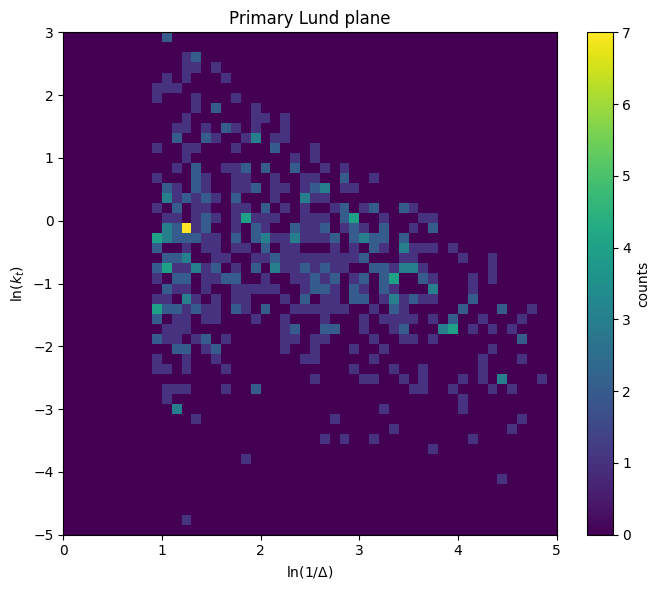

In [24]:
# ── Lund plane ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
Xc = 0.5 * (xedges[:-1] + xedges[1:])
Yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(Xc, Yc, indexing='ij')
pcm = ax.pcolormesh(X, Y, h2, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='counts')
ax.set_xlabel(r'$\ln(1/\Delta)$')
ax.set_ylabel(r'$\ln(k_t)$')
ax.set_title('Primary Lund plane')
plt.tight_layout()
plt.show()


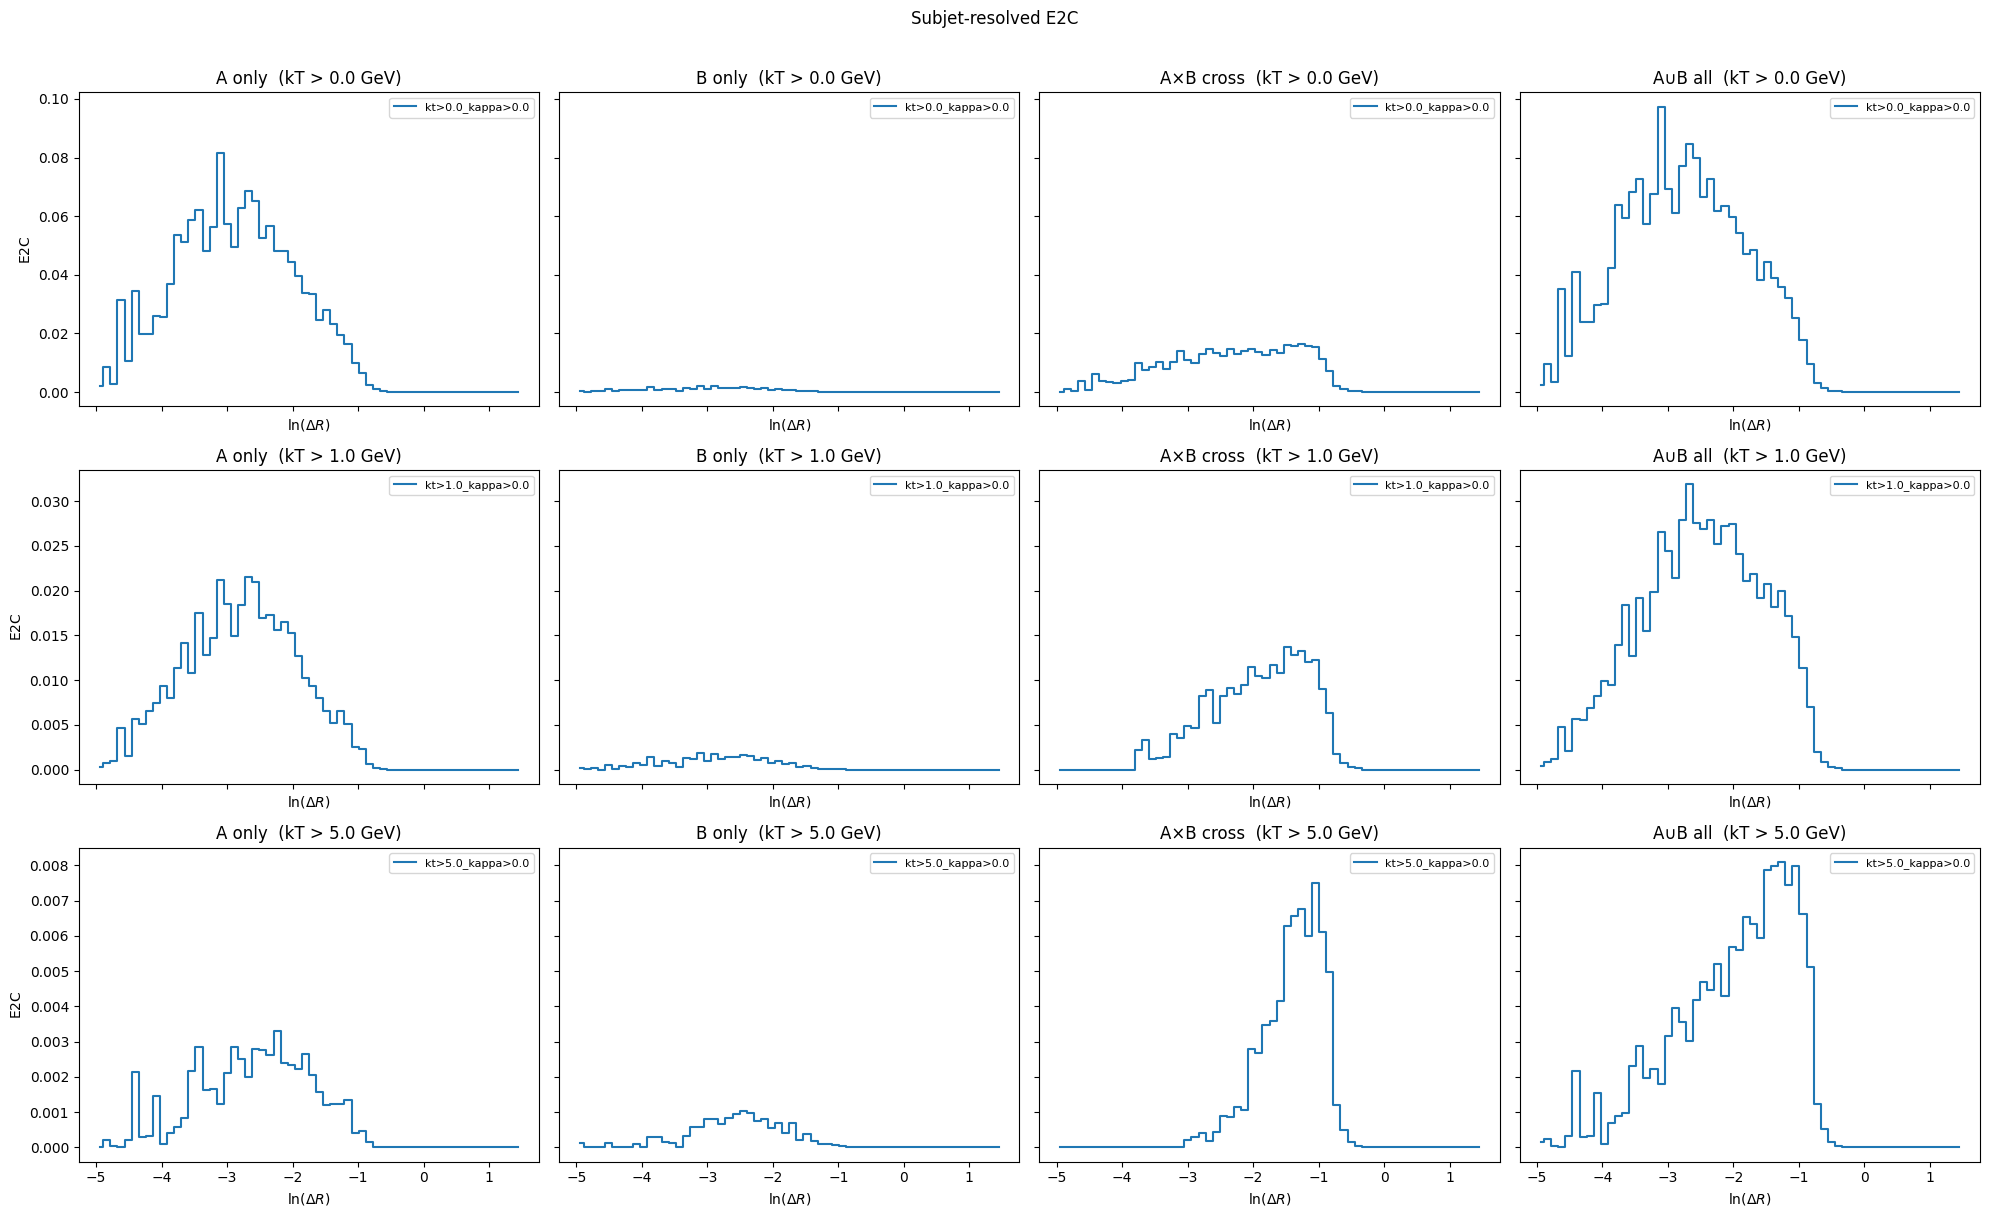

: 

In [ ]:
# ── E2C distributions per kT cut ─────────────────────────────────────────────
kt_cuts = sorted(eec_df['kt_cut'].unique())
types   = [('eec_AA', 'A only'),  ('eec_BB', 'B only'),
           ('eec_AB', 'A×B cross'), ('eec_all', 'A∪B all')]

fig, axes = plt.subplots(len(kt_cuts), len(types),
                         figsize=(5 * len(types), 4 * len(kt_cuts)),
                         sharey='row', sharex=True)
if len(kt_cuts) == 1:
    axes = [axes]   # keep 2-D indexing

for row, kt in enumerate(kt_cuts):
    sub = eec_df[eec_df['kt_cut'] == kt]
    for col, (col_name, title) in enumerate(types):
        ax = axes[row][col]
        for lbl, grp in sub.groupby('label'):
            ax.step(grp['ln_dR'], grp[col_name], where='mid', label=lbl)
        ax.set_title(f'{title}  (kT > {kt} GeV)')
        ax.set_xlabel(r'$\ln(\Delta R)$')
        if col == 0:
            ax.set_ylabel(r'$\mathrm{E2C}$')
        ax.legend(fontsize=8)

plt.suptitle('Subjet-resolved E2C', y=1.01)
plt.tight_layout()
plt.show()
